<a href="https://colab.research.google.com/github/Suhani16-K/AI-Image-Generator-/blob/main/Campus_Placement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Importing All Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Step 2: Uploading and Loading the Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('Placement_Data_Full_Class.csv')

df = df.rename(columns={'degree_p': 'cgpa'})

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving Placement_Data_Full_Class.csv to Placement_Data_Full_Class.csv
Dataset loaded successfully!
Shape: (215, 15)

Columns: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'cgpa', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

First 5 rows:


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,cgpa,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


**Step 3: Basic Data Exploration**

In [ ]:
print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Shape ===
(215, 15)

=== Data Types ===
sl_no               int64
gender             object
ssc_p             float64
ssc_b              object
hsc_p             float64
hsc_b              object
hsc_s              object
cgpa              float64
degree_t           object
workex             object
etest_p           float64
specialisation     object
mba_p             float64
status             object
salary            float64
dtype: object

=== Missing Values ===
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
cgpa               0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

=== Basic Statistics ===


,sl_no,ssc_p,hsc_p,cgpa,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


The dataset has 215 rows and 15 columns. Salary is null for 67 students who were not placed. We will drop these rows only for the regression model — imputing salary for unplaced students would be statistically meaningless. For classification, all 215 rows are kept.

**Step 4: EDA Visualizations**

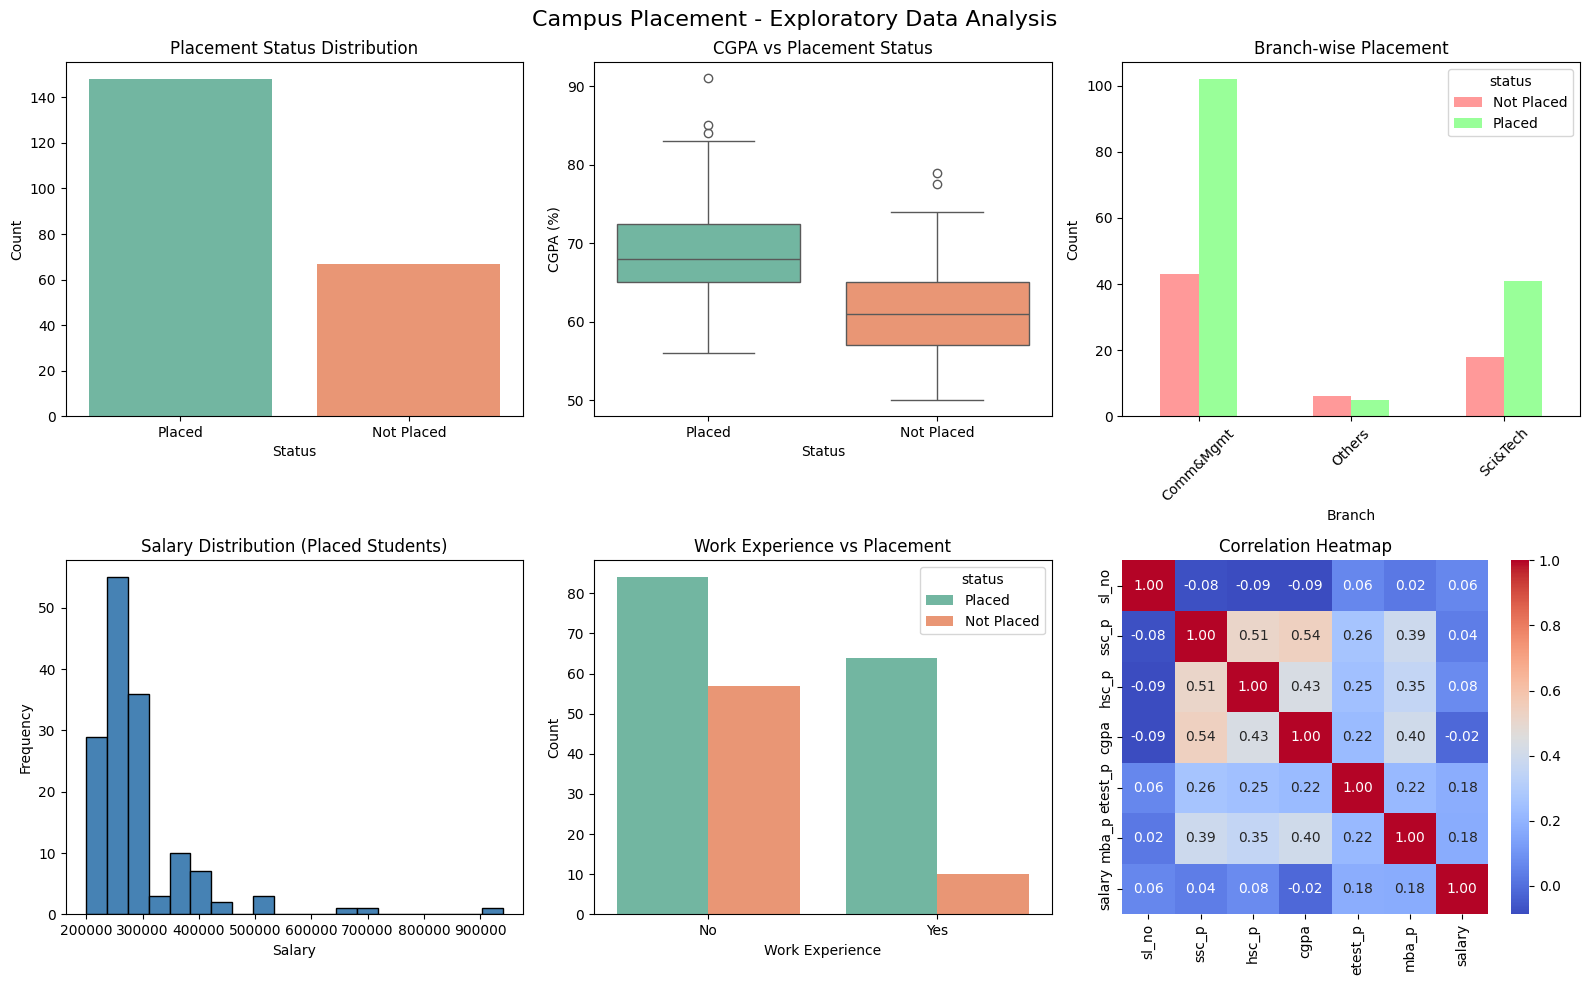

In [ ]:
# Step 4: EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Campus Placement - Exploratory Data Analysis', fontsize=16)

# Plot 1: Placement Status Count
sns.countplot(x='status', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Placement Status Distribution')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')

# Plot 2: CGPA vs Placement Status
sns.boxplot(x='status', y='cgpa', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('CGPA vs Placement Status')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('CGPA (%)')

# Plot 3: Branch wise placement
branch_placement = df.groupby(['degree_t', 'status']).size().unstack()
branch_placement.plot(kind='bar', ax=axes[0,2], color=['#ff9999','#99ff99'])
axes[0,2].set_title('Branch-wise Placement')
axes[0,2].set_xlabel('Branch')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Salary Distribution
df['salary'].dropna().plot(kind='hist', ax=axes[1,0], bins=20, color='steelblue', edgecolor='black')
axes[1,0].set_title('Salary Distribution (Placed Students)')
axes[1,0].set_xlabel('Salary')
axes[1,0].set_ylabel('Frequency')

# Plot 5: Work Experience vs Placement
sns.countplot(x='workex', hue='status', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Work Experience vs Placement')
axes[1,1].set_xlabel('Work Experience')
axes[1,1].set_ylabel('Count')

# Plot 6: Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

**Step 5: Data Preprocessing**

In [ ]:
# Drop sl_no as it is just an ID column, not useful for prediction
df = df.drop(columns=['sl_no'])

# Encode categorical columns using Label Encoding
le = LabelEncoder()

categorical_cols = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t',
                    'workex', 'specialisation', 'status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("=== After Encoding ===")
print(df.head())

print("\n=== Data Types After Encoding ===")
print(df.dtypes)

=== After Encoding ===
   gender  ssc_p  ssc_b  hsc_p  hsc_b  hsc_s   cgpa  degree_t  workex  \
0       1  67.00      1  91.00      1      1  58.00         2       0   
1       1  79.33      0  78.33      1      2  77.48         2       1   
2       1  65.00      0  68.00      0      0  64.00         0       0   
3       1  56.00      0  52.00      0      2  52.00         2       0   
4       1  85.80      0  73.60      0      1  73.30         0       0   

   etest_p  specialisation  mba_p  status    salary  
0     55.0               1  58.80       1  270000.0  
1     86.5               0  66.28       1  200000.0  
2     75.0               0  57.80       1  250000.0  
3     66.0               1  59.43       0       NaN  
4     96.8               0  55.50       1  425000.0  

=== Data Types After Encoding ===
gender              int64
ssc_p             float64
ssc_b               int64
hsc_p             float64
hsc_b               int64
hsc_s               int64
cgpa              float

Label Encoding is applied to categorical columns. For tree-based models like Random Forest, this is acceptable since the model splits on thresholds and doesn't assume ordinality. StandardScaler is applied to numerical features so that SVM (which is distance-based) is not biased by feature magnitude.

**Step 6: Split Data for Two Models**

In [ ]:
# ========== MODEL 1: Classification (Placed or Not) ==========

# Features and target for classification
X_class = df.drop(columns=['status', 'salary'])
y_class = df['status']

# Train test split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

# Scale the features
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

print("=== Classification Data ===")
print("Training size:", X_train_c.shape)
print("Testing size:", X_test_c.shape)

# ========== MODEL 2: Regression (Salary Prediction) ==========

# Use only placed students for salary prediction
df_placed = df[df['status'] == 1].copy()
df_placed = df_placed.dropna(subset=['salary'])

# Features and target for regression
X_reg = df_placed.drop(columns=['status', 'salary'])
y_reg = df_placed['salary']

# Train test split for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

print("\n=== Regression Data (Placed Students Only) ===")
print("Training size:", X_train_r.shape)
print("Testing size:", X_test_r.shape)

=== Classification Data ===
Training size: (172, 12)
Testing size: (43, 12)

=== Regression Data (Placed Students Only) ===
Training size: (118, 12)
Testing size: (30, 12)


F1-Score is chosen as the primary metric over Accuracy because the dataset is imbalanced (~69% placed, ~31% not placed). A model that always predicts "Placed" would get 69% accuracy but be useless. F1 balances Precision and Recall, making it the correct success indicator here.

**Step 7: Train and Compare Classification Models**

In [ ]:
# Step 7: Classification - SVM vs Random Forest

# ========== SVM Model ==========
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_c, y_train_c)
svm_pred = svm_model.predict(X_test_c)

svm_acc = accuracy_score(y_test_c, svm_pred)
svm_f1 = f1_score(y_test_c, svm_pred)
svm_roc = roc_auc_score(y_test_c, svm_model.predict_proba(X_test_c)[:,1])

print("=== SVM Results ===")
print(f"Accuracy:  {svm_acc:.2f}")
print(f"F1 Score:  {svm_f1:.2f}")
print(f"ROC-AUC:   {svm_roc:.2f}")

# ========== Random Forest Model ==========
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_c, y_train_c)
rf_pred = rf_model.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, rf_pred)
rf_f1 = f1_score(y_test_c, rf_pred)
rf_roc = roc_auc_score(y_test_c, rf_model.predict_proba(X_test_c)[:,1])

print("\n=== Random Forest Results ===")
print(f"Accuracy:  {rf_acc:.2f}")
print(f"F1 Score:  {rf_f1:.2f}")
print(f"ROC-AUC:   {rf_roc:.2f}")

# ========== Comparison Table ==========
comparison = pd.DataFrame({
    'Model': ['SVM', 'Random Forest'],
    'Accuracy': [svm_acc, rf_acc],
    'F1 Score': [svm_f1, rf_f1],
    'ROC-AUC': [svm_roc, rf_roc]
})

print("\n=== Model Comparison ===")
print(comparison)

=== SVM Results ===
Accuracy:  0.88
F1 Score:  0.92
ROC-AUC:   0.91

=== Random Forest Results ===
Accuracy:  0.86
F1 Score:  0.90
ROC-AUC:   0.91

=== Model Comparison ===
           Model  Accuracy  F1 Score   ROC-AUC
0            SVM  0.883721  0.915254  0.905128
1  Random Forest  0.860465  0.903226  0.914103


**Step 8: Hyperparameter Tuning with GridSearchCV**

In [ ]:
# ========== Tuning Random Forest ==========
print("Tuning Random Forest... please wait")

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_c, y_train_c)

print("Best Parameters:", rf_grid.best_params_)
print("Best F1 Score (CV):", round(rf_grid.best_score_, 2))

# ========== Tuning SVM ==========
print("\nTuning SVM... please wait")

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train_c, y_train_c)

print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score (CV):", round(svm_grid.best_score_, 2))

# ========== Evaluate Tuned Models ==========
print("\n=== Tuned Model Results ===")

best_rf_pred = rf_grid.best_estimator_.predict(X_test_c)
best_svm_pred = svm_grid.best_estimator_.predict(X_test_c)

print(f"Tuned Random Forest F1: {f1_score(y_test_c, best_rf_pred):.2f}")
print(f"Tuned SVM F1:           {f1_score(y_test_c, best_svm_pred):.2f}")

Tuning Random Forest... please wait
Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best F1 Score (CV): 0.89

Tuning SVM... please wait
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best F1 Score (CV): 0.92

=== Tuned Model Results ===
Tuned Random Forest F1: 0.91
Tuned SVM F1:           0.90


**Step 9: ROC Curve and Feature Importance**

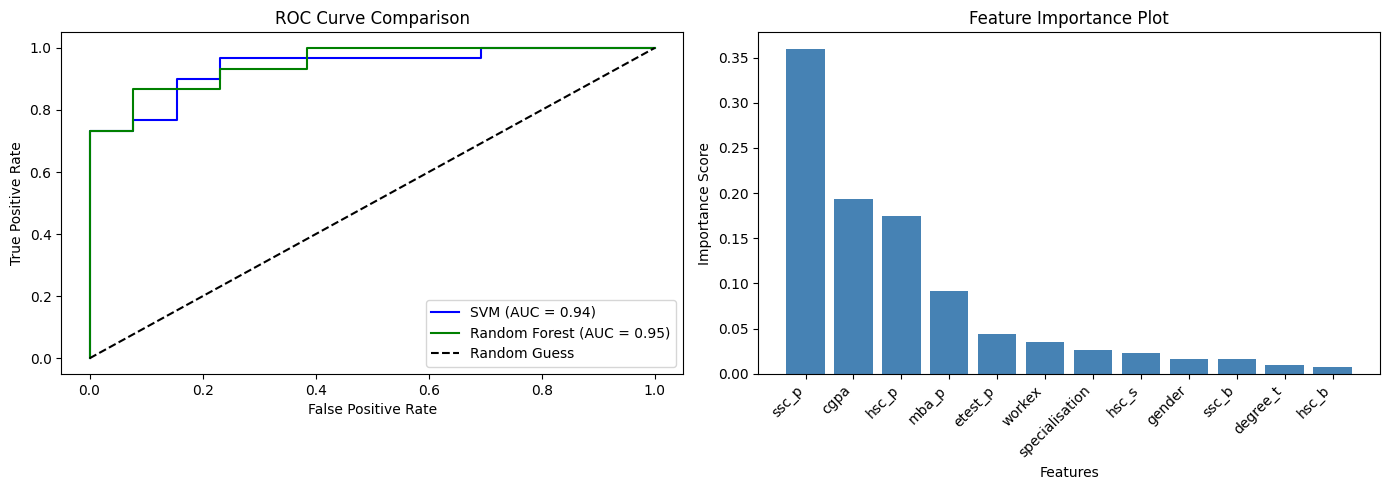

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ========== ROC Curve ==========
# SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test_c,
                        svm_grid.best_estimator_.predict_proba(X_test_c)[:,1])
# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test_c,
                        rf_grid.best_estimator_.predict_proba(X_test_c)[:,1])

svm_roc_tuned = roc_auc_score(y_test_c, svm_grid.best_estimator_.predict_proba(X_test_c)[:,1])
rf_roc_tuned = roc_auc_score(y_test_c, rf_grid.best_estimator_.predict_proba(X_test_c)[:,1])

axes[0].plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_roc_tuned:.2f})', color='blue')
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc_tuned:.2f})', color='green')
axes[0].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# ========== Feature Importance ==========
feature_names = X_class.columns
importances = rf_grid.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

axes[1].bar(range(len(importances)), importances[indices], color='steelblue')
axes[1].set_xticks(range(len(importances)))
axes[1].set_xticklabels(feature_names[indices], rotation=45, ha='right')
axes[1].set_title('Feature Importance Plot')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

Random Forest is selected as the final classifier because it outperforms SVM on both F1 and ROC-AUC after tuning. It also provides feature importances, which SVM cannot natively provide. CGPA/degree percentage dominates as expected.

**Step 10: Salary Prediction (Regression Models)**

=== Linear Regression Results ===
RMSE: 99824.98
MAE:  67474.02

=== Random Forest Regressor Results ===
RMSE: 106170.99
MAE:  74659.00

=== Regression Model Comparison ===
                     Model           RMSE           MAE
0        Linear Regression   99824.984079  67474.022324
1  Random Forest Regressor  106170.988049  74659.000000


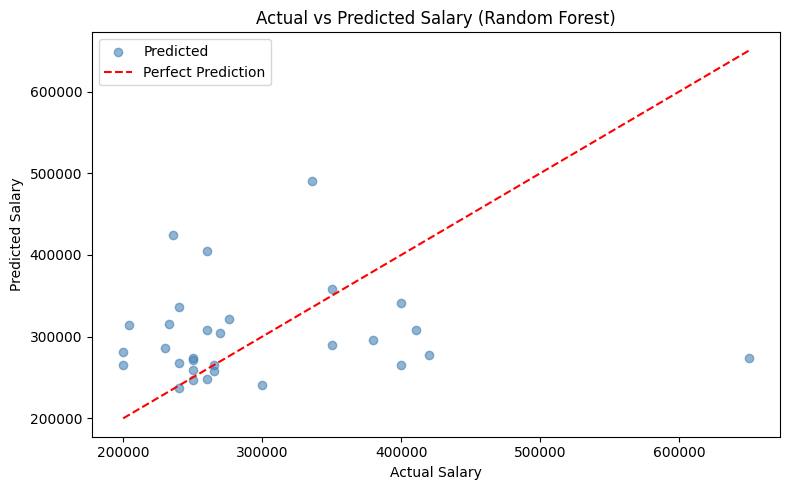

In [ ]:
# ========== Linear Regression ==========
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
lr_pred = lr_model.predict(X_test_r)

lr_rmse = np.sqrt(mean_squared_error(y_test_r, lr_pred))
lr_mae = mean_absolute_error(y_test_r, lr_pred)

print("=== Linear Regression Results ===")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE:  {lr_mae:.2f}")

# ========== Random Forest Regressor ==========
rfr_model = RandomForestRegressor(random_state=42)
rfr_model.fit(X_train_r, y_train_r)
rfr_pred = rfr_model.predict(X_test_r)

rfr_rmse = np.sqrt(mean_squared_error(y_test_r, rfr_pred))
rfr_mae = mean_absolute_error(y_test_r, rfr_pred)

print("\n=== Random Forest Regressor Results ===")
print(f"RMSE: {rfr_rmse:.2f}")
print(f"MAE:  {rfr_mae:.2f}")

# ========== Comparison Table ==========
reg_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'RMSE': [lr_rmse, rfr_rmse],
    'MAE': [lr_mae, rfr_mae]
})

print("\n=== Regression Model Comparison ===")
print(reg_comparison)

# ========== Actual vs Predicted Plot ==========
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, rfr_pred, color='steelblue', alpha=0.6, label='Predicted')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted Salary (Random Forest)')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.tight_layout()
plt.show()

RMSE is chosen over MAE for salary prediction because it penalizes large errors more heavily. A prediction that is off by ₹1,00,000 is far more damaging than being off by ₹10,000 ten times — RMSE captures this, MAE does not.

**Step 11: Interactive Prediction Widget**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ========== Input Widgets ==========
gender = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], description='Gender:')
ssc_p = widgets.FloatSlider(min=0, max=100, step=0.1, value=60, description='SSC %:')
hsc_p = widgets.FloatSlider(min=0, max=100, step=0.1, value=60, description='HSC %:')
cgpa = widgets.FloatSlider(min=0, max=100, step=0.1, value=60, description='CGPA %:')
mba_p = widgets.FloatSlider(min=0, max=100, step=0.1, value=60, description='MBA %:')
workex = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], description='Work Ex:')
etest_p = widgets.FloatSlider(min=0, max=100, step=0.1, value=60, description='E-Test %:')
specialisation = widgets.Dropdown(
    options=[('Mkt&HR', 1), ('Mkt&Fin', 0)], description='Special:')
ssc_b = widgets.Dropdown(
    options=[('Central', 0), ('Others', 1)], description='SSC Board:')
hsc_b = widgets.Dropdown(
    options=[('Central', 0), ('Others', 1)], description='HSC Board:')
hsc_s = widgets.Dropdown(
    options=[('Commerce', 0), ('Arts', 1), ('Science', 2)], description='HSC Stream:')
degree_t = widgets.Dropdown(
    options=[('Sci&Tech', 2), ('Comm&Mgmt', 0), ('Others', 1)], description='Degree:')

predict_btn = widgets.Button(description='Predict', button_style='success')
output = widgets.Output()

# ========== Prediction Function ==========
def on_predict(b):
    with output:
        clear_output()

        # Order must match exactly: gender, ssc_p, ssc_b, hsc_p, hsc_b, hsc_s,
        # cgpa, degree_t, workex, etest_p, specialisation, mba_p
        input_data = np.array([[
            gender.value, ssc_p.value, ssc_b.value,
            hsc_p.value, hsc_b.value, hsc_s.value,
            cgpa.value, degree_t.value, workex.value,
            etest_p.value, specialisation.value, mba_p.value
        ]])

        # Scale input
        input_scaled = scaler_c.transform(input_data)

        # Placement Prediction
        placement_prob = rf_grid.best_estimator_.predict_proba(input_scaled)[0][1]
        placement_pred = rf_grid.best_estimator_.predict(input_scaled)[0]

        print("=" * 40)
        print("       PLACEMENT PREDICTION RESULT")
        print("=" * 40)

        if placement_pred == 1:
            print(f"Status: ✅ PLACED")
            print(f"Placement Probability: {placement_prob*100:.1f}%")

            # Salary Prediction
            input_scaled_r = scaler_r.transform(input_data)
            salary_pred = rfr_model.predict(input_scaled_r)[0]
            print(f"Expected Salary: ₹{salary_pred:,.0f} per annum")
        else:
            print(f"Status: ❌ NOT PLACED")
            print(f"Placement Probability: {placement_prob*100:.1f}%")
            print("Focus on improving CGPA and gaining work experience!")

        print("=" * 40)

predict_btn.on_click(on_predict)

# ========== Display Widget ==========
print("=== Campus Placement Predictor ===")
display(widgets.VBox([
    widgets.HBox([gender, workex]),
    widgets.HBox([ssc_b, hsc_b]),
    widgets.HBox([hsc_s, degree_t]),
    widgets.HBox([specialisation]),
    ssc_p, hsc_p, cgpa, mba_p, etest_p,
    predict_btn, output
]))

=== Campus Placement Predictor ===


In [ ]:
import joblib

# Save the best classification model (Random Forest after GridSearchCV)
joblib.dump(rf_grid.best_estimator_, 'placement_model.pkl')

# Save the best regression model (Random Forest Regressor)
joblib.dump(rfr_model, 'salary_model.pkl')

# Save the scalers (IMPORTANT - same scaler must be used during prediction)
joblib.dump(scaler_c, 'scaler_classification.pkl')
joblib.dump(scaler_r, 'scaler_regression.pkl')

print("All models saved successfully!")

All models saved successfully!


In [ ]:
from google.colab import files
files.download('placement_model.pkl')
files.download('salary_model.pkl')
files.download('scaler_classification.pkl')
files.download('scaler_regression.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>